# Synthetic Seismograms — 2D Elastic Finite-Difference

Generate synthetic seismograms using a 2D **elastic** velocity-stress solver (P + S waves).  
Source is a moment tensor (earthquake double-couple); receivers record two-component particle velocity.  
Output traces are saved as `.npy` for WTMM/Hölder analysis in `wtmm_cpu_compressedsensing.ipynb`.

**Constitutive framework** — stress derives from a Helmholtz free energy Ψ(ε):
- σ = ∂Ψ/∂ε + χ,  where χ = ∂Φ̂/∂ε̇ (dissipative stress)
- This notebook: **Φ̂ = 0** (pure elastic) → σ = ∂Ψ/∂ε = C:ε (Hooke's law)
- Architecture supports swapping in viscoelastic/viscoplastic Φ̂ later

**Velocity models:**
1. **Sandwich** — layer A / layer B / layer A (validation: P and S arrivals with correct Vp/Vs ratio)
2. **Cantor set** (future) — self-similar impedance structure producing multifractal scattering

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

%matplotlib inline

## 2D Elastic Velocity-Stress FD Solver

**Thermomechanical framework**: the constitutive law derives from a scalar Helmholtz free energy Ψ(ε).
For linear isotropic elasticity: Ψ = ½ εᵢⱼ Cᵢⱼₖₗ εₖₗ (quadratic in strain), so the tangent stiffness ∂²Ψ/∂ε² = C is constant.

The dissipation potential Φ̂ = 0 for this step (pure elastic). Adding Φ̂ ≠ 0 later gives viscoelastic attenuation (Q), viscoplastic localisation, and the elastic–viscous transition at geological timescales (Deborah number D_e ≪ 1).

**Momentum equation** (never changes regardless of constitutive law):

$$\rho\,\frac{\partial v_x}{\partial t} = \frac{\partial \sigma_{xx}}{\partial x} + \frac{\partial \sigma_{xz}}{\partial z}, \qquad
\rho\,\frac{\partial v_z}{\partial t} = \frac{\partial \sigma_{xz}}{\partial x} + \frac{\partial \sigma_{zz}}{\partial z}$$

**Constitutive law** (from Ψ — the part that gets swapped):

$$\dot{\sigma}_{xx} = (\lambda + 2\mu)\,\frac{\partial v_x}{\partial x} + \lambda\,\frac{\partial v_z}{\partial z}, \qquad
\dot{\sigma}_{zz} = \lambda\,\frac{\partial v_x}{\partial x} + (\lambda + 2\mu)\,\frac{\partial v_z}{\partial z}, \qquad
\dot{\sigma}_{xz} = \mu\left(\frac{\partial v_x}{\partial z} + \frac{\partial v_z}{\partial x}\right)$$

- 4th-order staggered-grid spatial derivatives (Virieux 1986), 2nd-order leapfrog in time
- **5 fields**: vx, vz, σxx, σzz, σxz on staggered grid
- Free surface at z=0 (σzz = σxz = 0), absorbing sponge on left/right/bottom
- Source: moment tensor injection into stress components
- Receiver: records vx(t), vz(t) — two-component seismogram

In [144]:
# ---------------------------------------------------------------------------
# Source time functions
# ---------------------------------------------------------------------------

def ricker_wavelet(t, f0):
    """Ricker wavelet centered at t=0 with dominant frequency f0."""
    u = (np.pi * f0 * t) ** 2
    return (1.0 - 2.0 * u) * np.exp(-u)


def bandlimited_spike(t, f_max):
    """Band-limited spike: sinc(2·f_max·t). Flat spectrum up to f_max.

    Broadband source ideal for WTMM singularity analysis — does not
    impose its own spectral shape on the reflections.
    """
    arg = 2.0 * f_max * t
    return np.sinc(arg)  # np.sinc(x) = sin(π x) / (π x)


def brune_pulse(t, fc):
    """Brune omega-squared source time function.

    Moment rate: Ṁ(t) = M0 · (2π fc)² · t · exp(-2π fc t)  for t ≥ 0
    Flat below fc, falls as ω⁻² above — standard earthquake source model.
    """
    w = 2.0 * np.pi * fc
    s = np.where(t >= 0, w**2 * t * np.exp(-w * t), 0.0)
    return s


# ---------------------------------------------------------------------------
# Sponge absorbing boundary
# ---------------------------------------------------------------------------

def build_sponge(nx, nz, n_sponge, max_damp=0.015, free_surface=True):
    """Build 2D damping array. No sponge at top if free_surface=True."""
    damp = np.zeros((nx, nz), dtype=np.float64)
    for i in range(n_sponge):
        val = max_damp * ((n_sponge - i) / n_sponge) ** 2
        damp[i, :] = np.maximum(damp[i, :], val)          # left
        damp[nx - 1 - i, :] = np.maximum(damp[nx - 1 - i, :], val)  # right
        damp[:, nz - 1 - i] = np.maximum(damp[:, nz - 1 - i], val)  # bottom
        if not free_surface:
            damp[:, i] = np.maximum(damp[:, i], val)       # top
    return damp


# ---------------------------------------------------------------------------
# Constitutive function — the modular piece from Ψ
# ---------------------------------------------------------------------------

@njit
def hooke_stress_rate(dvx_dx, dvz_dz, dvx_dz, dvz_dx, lam, mu):
    """Stress rates from quadratic Helmholtz free energy Ψ = ½ ε:C:ε (isotropic).

    Tangent stiffness ∂²Ψ/∂ε² = C = constant (linear elastic).
    This is the function that gets swapped for nonlinear/anisotropic/dissipative.

    Returns (dσxx/dt, dσzz/dt, dσxz/dt).
    """
    dsxx = (lam + 2.0 * mu) * dvx_dx + lam * dvz_dz
    dszz = lam * dvx_dx + (lam + 2.0 * mu) * dvz_dz
    dsxz = mu * (dvx_dz + dvz_dx)
    return dsxx, dszz, dsxz


# ---------------------------------------------------------------------------
# Elastic velocity-stress FD kernel (Virieux 1986 staggered grid)
# ---------------------------------------------------------------------------

@njit(parallel=True)
def _elastic_vstress_step(vx, vz, sxx, szz, sxz,
                          lam, mu, buoy,
                          dt, damp, dx_inv, dz_inv, nx, nz):
    """One leapfrog step of the 2D elastic velocity-stress scheme.

    Staggered grid (Virieux 1986):
      σxx, σzz  at (i, j)       — cell centers (normal stresses)
      σxz       at (i+½, j+½)   — cell corners (shear stress)
      vx        at (i+½, j)     — x-staggered
      vz        at (i, j+½)     — z-staggered

    buoy = 1/ρ (buoyancy), pre-computed per grid point.

    Update order:
      1. Velocity gradients → stress update (constitutive law)
      2. Stress gradients → velocity update (momentum equation)
    """
    a1 = 9.0 / 8.0
    a2 = -1.0 / 24.0

    # --- 1. Stress update: σ̇ = ∂²Ψ/∂ε² : ε̇ ---
    sxx_new = sxx.copy()
    szz_new = szz.copy()
    sxz_new = sxz.copy()

    for ix in prange(nx):
        for iz in range(nz):
            # dvx/dx at (ix, iz) — from vx at (ix-½, iz)
            if ix < 2 or ix >= nx - 1:
                ixm = max(ix - 1, 0)
                dvx_dx = (vx[ix, iz] - vx[ixm, iz]) * dx_inv
            else:
                dvx_dx = (a1 * (vx[ix, iz] - vx[ix - 1, iz]) +
                          a2 * (vx[ix + 1, iz] - vx[ix - 2, iz])) * dx_inv

            # dvz/dz at (ix, iz) — from vz at (ix, iz-½)
            if iz < 2 or iz >= nz - 1:
                izm = max(iz - 1, 0)
                dvz_dz = (vz[ix, iz] - vz[ix, izm]) * dz_inv
            else:
                dvz_dz = (a1 * (vz[ix, iz] - vz[ix, iz - 1]) +
                          a2 * (vz[ix, iz + 1] - vz[ix, iz - 2])) * dz_inv

            # dvx/dz at (ix+½, iz+½) — from vx at (ix+½, iz)
            if iz < 1 or iz >= nz - 2:
                izp = min(iz + 1, nz - 1)
                dvx_dz = (vx[ix, izp] - vx[ix, iz]) * dz_inv
            else:
                dvx_dz = (a1 * (vx[ix, iz + 1] - vx[ix, iz]) +
                          a2 * (vx[ix, iz + 2] - vx[ix, iz - 1])) * dz_inv

            # dvz/dx at (ix+½, iz+½) — from vz at (ix, iz+½)
            if ix < 1 or ix >= nx - 2:
                ixp = min(ix + 1, nx - 1)
                dvz_dx = (vz[ixp, iz] - vz[ix, iz]) * dx_inv
            else:
                dvz_dx = (a1 * (vz[ix + 1, iz] - vz[ix, iz]) +
                          a2 * (vz[ix + 2, iz] - vz[ix - 1, iz])) * dx_inv

            # Constitutive law: σ̇ = C : ε̇
            dsxx, dszz, dsxz = hooke_stress_rate(
                dvx_dx, dvz_dz, dvx_dz, dvz_dx, lam[ix, iz], mu[ix, iz])

            d = 1.0 - damp[ix, iz]
            sxx_new[ix, iz] = sxx[ix, iz] * d + dt * dsxx
            szz_new[ix, iz] = szz[ix, iz] * d + dt * dszz
            sxz_new[ix, iz] = sxz[ix, iz] * d + dt * dsxz

    # --- 2. Velocity update: ρ v̇ = ∇·σ (momentum equation) ---
    vx_new = vx.copy()
    vz_new = vz.copy()

    for ix in prange(nx):
        for iz in range(nz):
            # dσxx/dx at (ix+½, iz) — from σxx at (ix, iz)
            if ix < 1 or ix >= nx - 2:
                ixp = min(ix + 1, nx - 1)
                dsxx_dx = (sxx_new[ixp, iz] - sxx_new[ix, iz]) * dx_inv
            else:
                dsxx_dx = (a1 * (sxx_new[ix + 1, iz] - sxx_new[ix, iz]) +
                           a2 * (sxx_new[ix + 2, iz] - sxx_new[ix - 1, iz])) * dx_inv

            # dσxz/dz at (ix+½, iz) — from σxz at (ix+½, iz+½)
            if iz < 2 or iz >= nz - 1:
                izm = max(iz - 1, 0)
                dsxz_dz = (sxz_new[ix, iz] - sxz_new[ix, izm]) * dz_inv
            else:
                dsxz_dz = (a1 * (sxz_new[ix, iz] - sxz_new[ix, iz - 1]) +
                           a2 * (sxz_new[ix, iz + 1] - sxz_new[ix, iz - 2])) * dz_inv

            # dσxz/dx at (ix, iz+½) — from σxz at (ix+½, iz+½)
            if ix < 2 or ix >= nx - 1:
                ixm = max(ix - 1, 0)
                dsxz_dx = (sxz_new[ix, iz] - sxz_new[ixm, iz]) * dx_inv
            else:
                dsxz_dx = (a1 * (sxz_new[ix, iz] - sxz_new[ix - 1, iz]) +
                           a2 * (sxz_new[ix + 1, iz] - sxz_new[ix - 2, iz])) * dx_inv

            # dσzz/dz at (ix, iz+½) — from σzz at (ix, iz)
            if iz < 1 or iz >= nz - 2:
                izp = min(iz + 1, nz - 1)
                dszz_dz = (szz_new[ix, izp] - szz_new[ix, iz]) * dz_inv
            else:
                dszz_dz = (a1 * (szz_new[ix, iz + 1] - szz_new[ix, iz]) +
                           a2 * (szz_new[ix, iz + 2] - szz_new[ix, iz - 1])) * dz_inv

            d = 1.0 - damp[ix, iz]
            # buoy averaged to staggered positions
            b_x = 0.5 * (buoy[min(ix + 1, nx - 1), iz] + buoy[ix, iz])
            b_z = 0.5 * (buoy[ix, min(iz + 1, nz - 1)] + buoy[ix, iz])

            vx_new[ix, iz] = vx[ix, iz] * d + dt * b_x * (dsxx_dx + dsxz_dz)
            vz_new[ix, iz] = vz[ix, iz] * d + dt * b_z * (dsxz_dx + dszz_dz)

    return vx_new, vz_new, sxx_new, szz_new, sxz_new


# ---------------------------------------------------------------------------
# Simulation driver
# ---------------------------------------------------------------------------

def run_fd_simulation(vp_model, vs_model, rho_model, dx, dz, dt, nt,
                      src_pos, rec_pos,
                      source_fn='spike', f_max=None, fc=None, f0=None,
                      moment=(0.0, 0.0, 1.0),
                      n_sponge=30, free_surface=True):
    """Run 2D elastic velocity-stress FD simulation.

    Parameters
    ----------
    vp_model, vs_model, rho_model : (nx, nz) arrays
    dx, dz : grid spacing (m)
    dt : time step (s)
    nt : number of time steps
    src_pos : (ix, iz) source grid indices
    rec_pos : (ix, iz) receiver grid indices
    source_fn : 'spike' (band-limited), 'brune', or 'ricker'
    f_max : max frequency for band-limited spike (Hz)
    fc : corner frequency for Brune pulse (Hz)
    f0 : dominant frequency for Ricker wavelet (Hz)
    moment : (Mxx, Mzz, Mxz) moment tensor components (relative)
    n_sponge : sponge thickness in grid points
    free_surface : enforce traction-free at z=0

    Returns
    -------
    traces : dict with 'vx', 'vz' arrays of shape (nt,)
    surface_gather : dict with 'vx', 'vz' arrays of shape (nx, nt)
    times : (nt,) time array
    """
    nx, nz = vp_model.shape

    # Lamé parameters from Vp, Vs, ρ
    mu = rho_model * vs_model**2
    lam = rho_model * vp_model**2 - 2.0 * mu
    buoy = 1.0 / rho_model  # buoyancy = 1/ρ

    dx_inv = 1.0 / dx
    dz_inv = 1.0 / dz
    damp = build_sponge(nx, nz, n_sponge, free_surface=free_surface)

    # Source time function
    times = np.arange(nt) * dt
    if source_fn == 'spike':
        if f_max is None:
            f_max = 0.8 * vs_model.min() / (5.0 * dx)
        t_shift = 1.5 / f_max
        stf = bandlimited_spike(times - t_shift, f_max)
    elif source_fn == 'brune':
        if fc is None:
            fc = 20.0
        t_shift = 0.0  # Brune is causal
        stf = brune_pulse(times - t_shift, fc)
    else:  # ricker
        if f0 is None:
            f0 = 20.0
        t_shift = 1.5 / f0
        stf = ricker_wavelet(times - t_shift, f0)

    # Normalize STF so peak amplitude = 1
    stf_max = np.abs(stf).max()
    if stf_max > 0:
        stf = stf / stf_max

    # Moment tensor components
    Mxx, Mzz, Mxz = moment

    # Fields
    vx = np.zeros((nx, nz), dtype=np.float64)
    vz = np.zeros((nx, nz), dtype=np.float64)
    sxx = np.zeros((nx, nz), dtype=np.float64)
    szz = np.zeros((nx, nz), dtype=np.float64)
    sxz = np.zeros((nx, nz), dtype=np.float64)

    trace_vx = np.zeros(nt, dtype=np.float64)
    trace_vz = np.zeros(nt, dtype=np.float64)

    # Surface gather: record both components at source depth
    surface_iz = src_pos[1]
    sg_vx = np.zeros((nx, nt), dtype=np.float64)
    sg_vz = np.zeros((nx, nt), dtype=np.float64)

    sx, sz = src_pos
    rx, rz = rec_pos

    for it in range(nt):
        vx, vz, sxx, szz, sxz = _elastic_vstress_step(
            vx, vz, sxx, szz, sxz,
            lam, mu, buoy,
            dt, damp, dx_inv, dz_inv, nx, nz)

        # Moment tensor source: inject Ṁ into stress components
        # σ̇ᵢⱼ += Mᵢⱼ · s(t) / (dx·dz)  (point source, area normalization)
        src_amp = stf[it] / (dx * dz)
        sxx[sx, sz] += dt * Mxx * src_amp
        szz[sx, sz] += dt * Mzz * src_amp
        sxz[sx, sz] += dt * Mxz * src_amp

        # Free surface: traction-free boundary at z=0
        if free_surface:
            szz[:, 0] = 0.0
            sxz[:, 0] = 0.0

        # Record at receiver
        trace_vx[it] = vx[rx, rz]
        trace_vz[it] = vz[rx, rz]

        # Surface gather
        sg_vx[:, it] = vx[:, surface_iz]
        sg_vz[:, it] = vz[:, surface_iz]

    traces = {'vx': trace_vx, 'vz': trace_vz}
    surface_gather = {'vx': sg_vx, 'vz': sg_vz}
    return traces, surface_gather, times

## Velocity Model Builders

In [145]:
def make_sandwich_model(nx, nz, dx,
                        vp_a=5000.0, vs_a=2900.0, rho_a=2700.0,
                        vp_b=3000.0, vs_b=1500.0, rho_b=2500.0,
                        z_top=1000.0, z_bot=2000.0):
    """Horizontal sandwich: layer A / layer B / layer A.

    Returns (vp, vs, rho) arrays. Default Vp/Vs ≈ 1.72 (Poisson solid).
    """
    vp = np.full((nx, nz), vp_a, dtype=np.float64)
    vs = np.full((nx, nz), vs_a, dtype=np.float64)
    rho = np.full((nx, nz), rho_a, dtype=np.float64)
    iz_top = int(z_top / dx)
    iz_bot = int(z_bot / dx)
    vp[:, iz_top:iz_bot] = vp_b
    vs[:, iz_top:iz_bot] = vs_b
    rho[:, iz_top:iz_bot] = rho_b
    return vp, vs, rho


def make_cantor_model(nx, nz, dx,
                      vp_a=5000.0, vs_a=2900.0, rho_a=2700.0,
                      vp_b=3000.0, vs_b=1500.0, rho_b=2500.0,
                      n_iterations=4, z_min=200.0, z_max=2800.0):
    """Cantor set distribution of layer A in depth, layer B fills gaps.

    Returns (vp, vs, rho) arrays.
    Builds a standard middle-third Cantor set: at each iteration,
    the middle third of each remaining interval is removed (set to B).
    """
    vp = np.full((nx, nz), vp_b, dtype=np.float64)
    vs = np.full((nx, nz), vs_b, dtype=np.float64)
    rho = np.full((nx, nz), rho_b, dtype=np.float64)

    intervals = [(z_min, z_max)]
    for _ in range(n_iterations):
        new_intervals = []
        for lo, hi in intervals:
            third = (hi - lo) / 3.0
            new_intervals.append((lo, lo + third))
            new_intervals.append((hi - third, hi))
        intervals = new_intervals

    for lo, hi in intervals:
        iz_lo = max(0, min(int(lo / dx), nz))
        iz_hi = max(0, min(int(hi / dx), nz))
        vp[:, iz_lo:iz_hi] = vp_a
        vs[:, iz_lo:iz_hi] = vs_a
        rho[:, iz_lo:iz_hi] = rho_a

    return vp, vs, rho

## Sandwich Simulation — Elastic (P + S waves)

In [146]:
# --- Grid and physical parameters ---
dx = dz = 10.0            # m (grid spacing)
x_extent = 2000.0         # m (physical horizontal extent)
z_extent = 3000.0         # m (physical depth)
n_sponge = 30             # sponge thickness in grid points

nx = int((x_extent + 2 * n_sponge * dx) / dx)
nz = int((z_extent + n_sponge * dz) / dz)

# Layer properties: A (fast) / B (slow) / A (fast)
vp_a, vs_a, rho_a = 5000.0, 2900.0, 2700.0  # Vp/Vs ≈ 1.72
vp_b, vs_b, rho_b = 3000.0, 1500.0, 2500.0  # Vp/Vs = 2.00

# CFL condition — 4th-order staggered grid, based on Vp_max
cfl = 0.5
vp_max = max(vp_a, vp_b)
vs_min = min(vs_a, vs_b)
dt = cfl * dx / vp_max
T_total = 5.0             # seconds
nt = int(T_total / dt)

# Band-limited spike: f_max from Vs_min sampling requirement
f_max = vs_min / (5.0 * dx)

# Moment tensor: 45° thrust fault (double-couple)
# Strike-slip: Mxx = -M0, Mzz = M0, Mxz = 0
# 45° thrust:  Mxx = 0,   Mzz = 0,  Mxz = M0
M0 = 1.0
moment = (-M0, M0, 0.0)  # strike-slip for clear radiation pattern

print(f"Grid: {nx} x {nz}, dx={dx} m")
print(f"Physical domain: {nx*dx:.0f} m x {nz*dz:.0f} m")
print(f"dt = {dt*1e3:.4f} ms, nt = {nt}, T = {T_total:.1f} s")
print(f"CFL (P-wave) = {vp_max * dt / dx:.3f}")
print(f"CFL (S-wave) = {vs_min * dt / dx:.3f}")
print(f"\nLayer A: Vp={vp_a:.0f}, Vs={vs_a:.0f}, ρ={rho_a:.0f}, Vp/Vs={vp_a/vs_a:.2f}")
print(f"Layer B: Vp={vp_b:.0f}, Vs={vs_b:.0f}, ρ={rho_b:.0f}, Vp/Vs={vp_b/vs_b:.2f}")
print(f"f_max (band-limited spike) = {f_max:.1f} Hz")
print(f"Min P-wavelength ≈ {vp_b / (2.5 * f_max):.0f} m → {vp_b / (2.5 * f_max) / dx:.1f} pts/λ_min")
print(f"Min S-wavelength ≈ {vs_min / (2.5 * f_max):.0f} m → {vs_min / (2.5 * f_max) / dx:.1f} pts/λ_min")
print(f"Moment tensor: Mxx={moment[0]}, Mzz={moment[1]}, Mxz={moment[2]}")

# --- Build velocity model ---
vp, vs, rho = make_sandwich_model(nx, nz, dx,
                                   vp_a=vp_a, vs_a=vs_a, rho_a=rho_a,
                                   vp_b=vp_b, vs_b=vs_b, rho_b=rho_b,
                                   z_top=1000.0, z_bot=2000.0)

# --- Source and receiver at the surface, 2 km apart ---
src_pos = (n_sponge, 2)
rec_pos = (nx - n_sponge - 1, 2)

print(f"\nSource:   ix={src_pos[0]}, iz={src_pos[1]} → "
      f"x={src_pos[0]*dx:.0f} m, z={src_pos[1]*dz:.0f} m")
print(f"Receiver: ix={rec_pos[0]}, iz={rec_pos[1]} → "
      f"x={rec_pos[0]*dx:.0f} m, z={rec_pos[1]*dz:.0f} m")
print(f"Offset:   {(rec_pos[0] - src_pos[0]) * dx:.0f} m")

# --- Run simulation ---
traces, surface_gather, times = run_fd_simulation(
    vp, vs, rho, dx, dz, dt, nt, src_pos, rec_pos,
    source_fn='spike', f_max=f_max,
    moment=moment,
    n_sponge=n_sponge, free_surface=True
)
print(f"\nSimulation complete.")
print(f"Trace vx range: [{traces['vx'].min():.4e}, {traces['vx'].max():.4e}]")
print(f"Trace vz range: [{traces['vz'].min():.4e}, {traces['vz'].max():.4e}]")

Grid: 260 x 330, dx=10.0 m
Physical domain: 2600 m x 3300 m
dt = 1.0000 ms, nt = 5000, T = 5.0 s
CFL (P-wave) = 0.500
CFL (S-wave) = 0.150

Layer A: Vp=5000, Vs=2900, ρ=2700, Vp/Vs=1.72
Layer B: Vp=3000, Vs=1500, ρ=2500, Vp/Vs=2.00
f_max (band-limited spike) = 30.0 Hz
Min P-wavelength ≈ 40 m → 4.0 pts/λ_min
Min S-wavelength ≈ 20 m → 2.0 pts/λ_min
Moment tensor: Mxx=-1.0, Mzz=1.0, Mxz=0.0

Source:   ix=30, iz=2 → x=300 m, z=20 m
Receiver: ix=229, iz=2 → x=2290 m, z=20 m
Offset:   1990 m

Simulation complete.
Trace vx range: [-1.0510e-14, 1.0790e-14]
Trace vz range: [-7.2031e-15, 8.1980e-15]


## Seismograms

Recorded traces at the receiver — this is the "data" we'd have in practice (no knowledge of the velocity model).

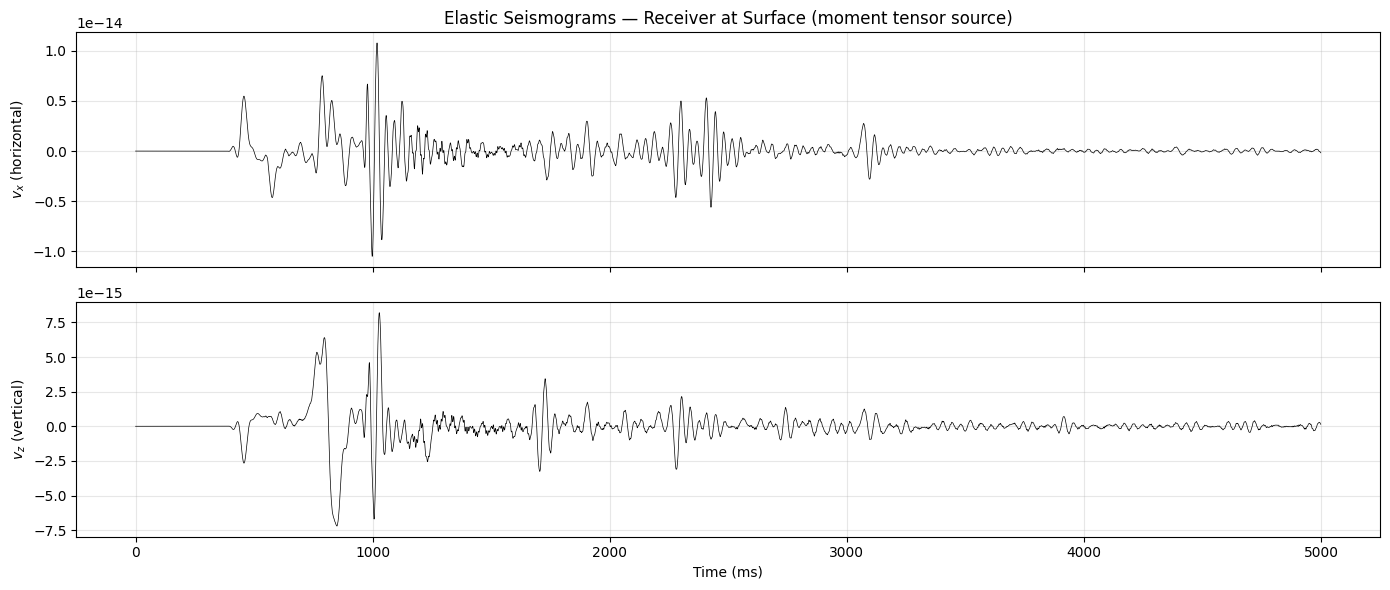

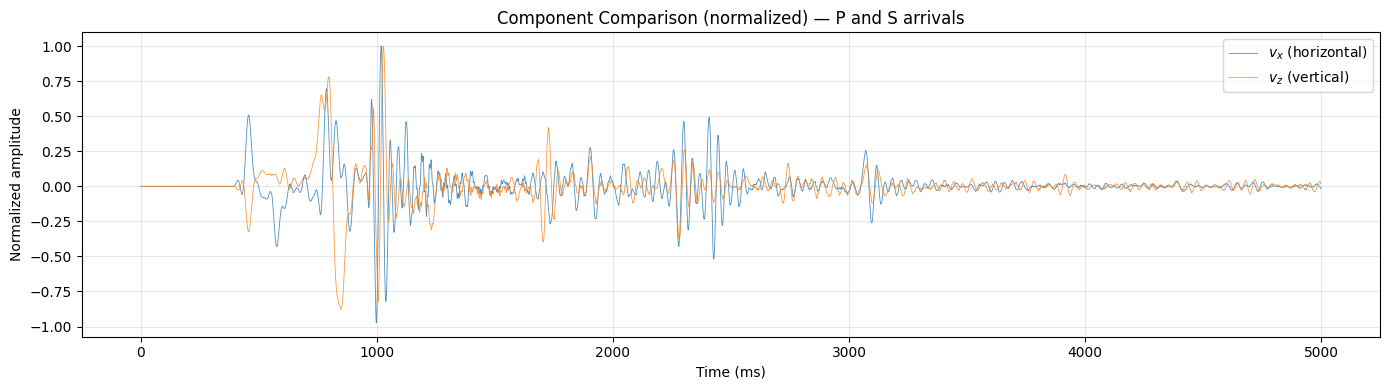

Saved traces (5000 samples, dt=1.0000 ms, T=5.0 s)


In [147]:
t_ms = times * 1e3

# --- Two-component seismogram (true amplitude) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, (key, label) in zip(axes, [('vx', '$v_x$ (horizontal)'),
                                     ('vz', '$v_z$ (vertical)')]):
    ax.plot(t_ms, traces[key], 'k', lw=0.5)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (ms)')
axes[0].set_title('Elastic Seismograms — Receiver at Surface (moment tensor source)')
plt.tight_layout()
plt.show()

# --- Normalized overlay for waveform comparison ---
fig, ax = plt.subplots(figsize=(14, 4))
for key, label, color in [('vx', '$v_x$ (horizontal)', 'C0'),
                            ('vz', '$v_z$ (vertical)', 'C1')]:
    tr = traces[key]
    mx = np.abs(tr).max()
    if mx > 0:
        ax.plot(t_ms, tr / mx, color=color, lw=0.6, label=label, alpha=0.8)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Normalized amplitude')
ax.set_title('Component Comparison (normalized) — P and S arrivals')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Export traces ---
np.save('sandwich_trace_vx.npy', traces['vx'])
np.save('sandwich_trace_vz.npy', traces['vz'])
np.save('sandwich_trace_times.npy', times)
print(f"Saved traces ({len(times)} samples, dt={dt*1e3:.4f} ms, T={T_total:.1f} s)")

## Simulation Verification

Velocity model and two-component surface gathers — vx and vz recorded at all surface positions.  
The x-t gathers show P-wave and S-wave arrivals with different moveout velocities.  
Double-couple radiation pattern should produce different polarity patterns in each component.

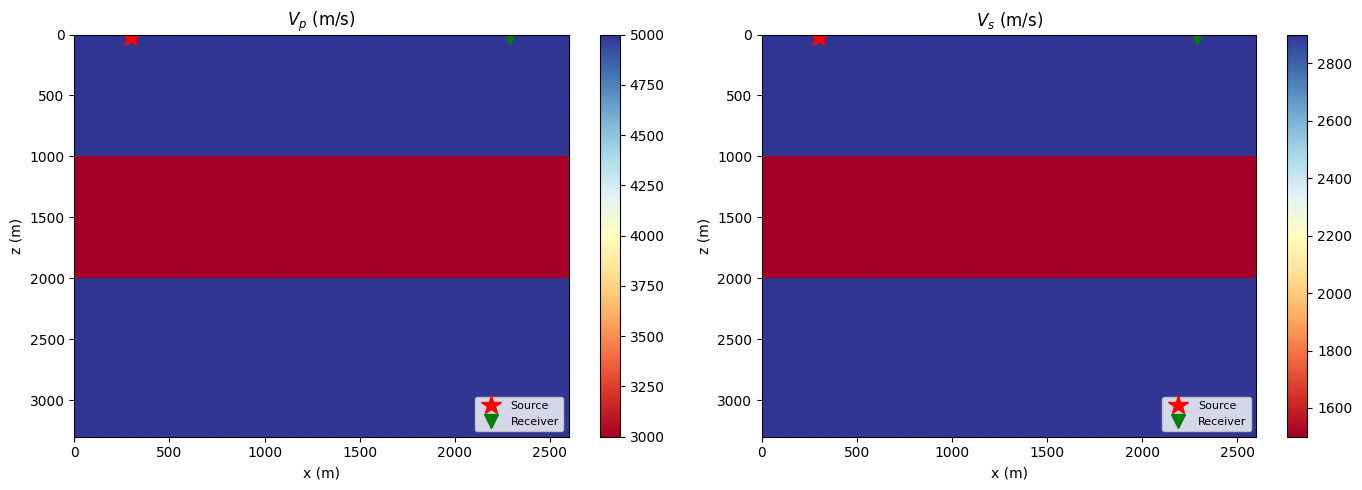

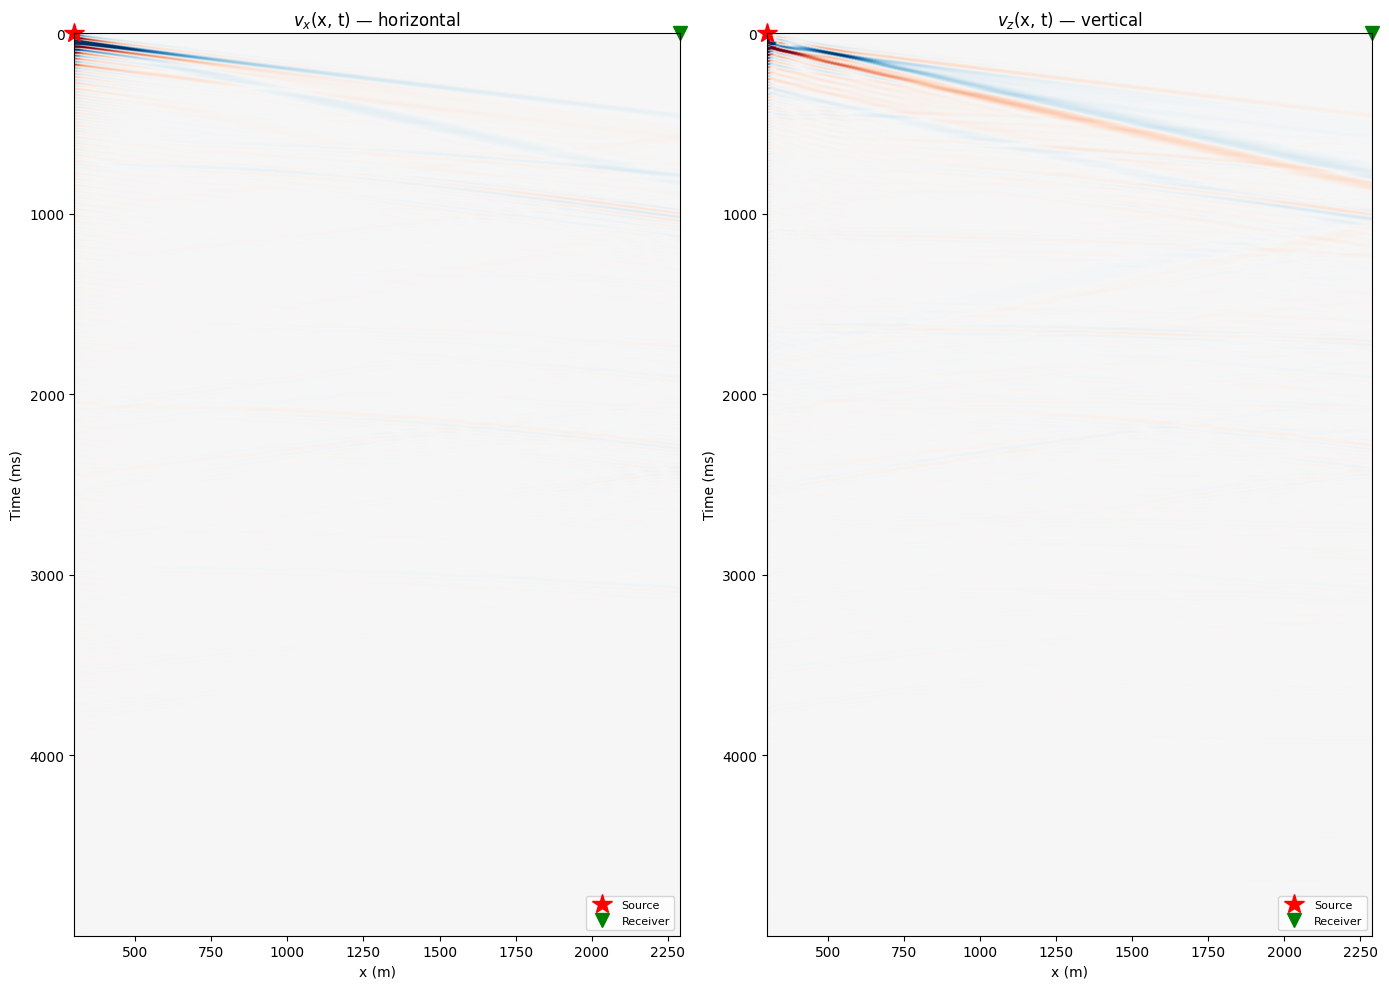

In [148]:
extent_model = [0, nx * dx, nz * dz, 0]

# --- Velocity model (Vp) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (model, title, cmap) in zip(axes,
        [(vp, '$V_p$ (m/s)', 'RdYlBu'), (vs, '$V_s$ (m/s)', 'RdYlBu')]):
    im = ax.imshow(model.T, aspect='auto', extent=extent_model, cmap=cmap)
    ax.plot(src_pos[0] * dx, src_pos[1] * dz, 'r*', ms=15, label='Source')
    ax.plot(rec_pos[0] * dx, rec_pos[1] * dz, 'gv', ms=10, label='Receiver')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('z (m)')
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=8)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# --- Two-component surface gathers ---
gather_vx = surface_gather['vx'][n_sponge:nx - n_sponge, :]
gather_vz = surface_gather['vz'][n_sponge:nx - n_sponge, :]
t_ms = times * 1e3
x_phys = np.arange(n_sponge, nx - n_sponge) * dx
extent_xt = [x_phys[0], x_phys[-1], t_ms[-1], t_ms[0]]

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
for ax, (gather, label) in zip(axes,
        [(gather_vx, '$v_x$(x, t) — horizontal'),
         (gather_vz, '$v_z$(x, t) — vertical')]):
    vmax = np.abs(gather).max() * 0.1
    if vmax == 0:
        vmax = 1.0
    ax.imshow(gather.T, aspect='auto', extent=extent_xt,
              cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.plot(src_pos[0] * dx, 0, 'r*', ms=15, clip_on=False, label='Source')
    ax.plot(rec_pos[0] * dx, 0, 'gv', ms=10, clip_on=False, label='Receiver')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('Time (ms)')
    ax.set_title(label)
    ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

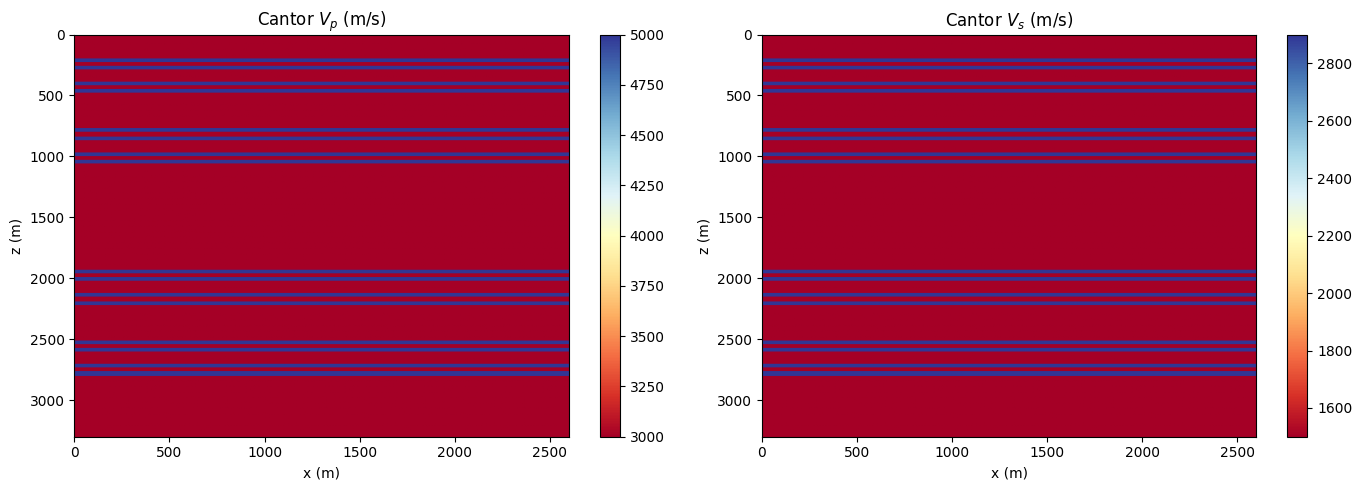

In [149]:
# --- Preview the Cantor velocity model ---
vp_cantor, vs_cantor, rho_cantor = make_cantor_model(
    nx, nz, dx,
    vp_a=vp_a, vs_a=vs_a, rho_a=rho_a,
    vp_b=vp_b, vs_b=vs_b, rho_b=rho_b,
    n_iterations=4, z_min=200.0, z_max=2800.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (model, title) in zip(axes,
        [(vp_cantor, 'Cantor $V_p$ (m/s)'), (vs_cantor, 'Cantor $V_s$ (m/s)')]):
    im = ax.imshow(model.T, aspect='auto', extent=extent_model, cmap='RdYlBu')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('z (m)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Uncomment to run the Cantor simulation:
# traces_cantor, sg_cantor, times_cantor = run_fd_simulation(
#     vp_cantor, vs_cantor, rho_cantor, dx, dz, dt, nt, src_pos, rec_pos,
#     source_fn='spike', f_max=f_max, moment=moment,
#     n_sponge=n_sponge, free_surface=True
# )
# np.save('cantor_trace_vx.npy', traces_cantor['vx'])
# np.save('cantor_trace_vz.npy', traces_cantor['vz'])
# np.save('cantor_trace_times.npy', times_cantor)

In [150]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

%matplotlib inline
print("Imports OK")

Imports OK


In [151]:
# ---------------------------------------------------------------------------
# Source time functions
# ---------------------------------------------------------------------------

def ricker_wavelet(t, f0):
    """Ricker wavelet centered at t=0 with dominant frequency f0."""
    u = (np.pi * f0 * t) ** 2
    return (1.0 - 2.0 * u) * np.exp(-u)


def bandlimited_spike(t, f_max):
    """Band-limited spike: sinc(2·f_max·t). Flat spectrum up to f_max."""
    arg = 2.0 * f_max * t
    return np.sinc(arg)


def brune_pulse(t, fc):
    """Brune omega-squared source time function."""
    w = 2.0 * np.pi * fc
    s = np.where(t >= 0, w**2 * t * np.exp(-w * t), 0.0)
    return s


# ---------------------------------------------------------------------------
# Sponge absorbing boundary
# ---------------------------------------------------------------------------

def build_sponge(nx, nz, n_sponge, max_damp=0.015, free_surface=True):
    """Build 2D damping array. No sponge at top if free_surface=True."""
    damp = np.zeros((nx, nz), dtype=np.float64)
    for i in range(n_sponge):
        val = max_damp * ((n_sponge - i) / n_sponge) ** 2
        damp[i, :] = np.maximum(damp[i, :], val)
        damp[nx - 1 - i, :] = np.maximum(damp[nx - 1 - i, :], val)
        damp[:, nz - 1 - i] = np.maximum(damp[:, nz - 1 - i], val)
        if not free_surface:
            damp[:, i] = np.maximum(damp[:, i], val)
    return damp


# ---------------------------------------------------------------------------
# Constitutive function
# ---------------------------------------------------------------------------

@njit
def hooke_stress_rate(dvx_dx, dvz_dz, dvx_dz, dvz_dx, lam, mu):
    """Stress rates from Ψ = ½ ε:C:ε (isotropic linear elastic)."""
    dsxx = (lam + 2.0 * mu) * dvx_dx + lam * dvz_dz
    dszz = lam * dvx_dx + (lam + 2.0 * mu) * dvz_dz
    dsxz = mu * (dvx_dz + dvz_dx)
    return dsxx, dszz, dsxz


# ---------------------------------------------------------------------------
# Elastic velocity-stress FD kernel
# ---------------------------------------------------------------------------

@njit(parallel=True)
def _elastic_vstress_step(vx, vz, sxx, szz, sxz,
                          lam, mu, buoy,
                          dt, damp, dx_inv, dz_inv, nx, nz):
    a1 = 9.0 / 8.0
    a2 = -1.0 / 24.0

    sxx_new = sxx.copy()
    szz_new = szz.copy()
    sxz_new = sxz.copy()

    for ix in prange(nx):
        for iz in range(nz):
            if ix < 2 or ix >= nx - 1:
                ixm = max(ix - 1, 0)
                dvx_dx = (vx[ix, iz] - vx[ixm, iz]) * dx_inv
            else:
                dvx_dx = (a1 * (vx[ix, iz] - vx[ix - 1, iz]) +
                          a2 * (vx[ix + 1, iz] - vx[ix - 2, iz])) * dx_inv

            if iz < 2 or iz >= nz - 1:
                izm = max(iz - 1, 0)
                dvz_dz = (vz[ix, iz] - vz[ix, izm]) * dz_inv
            else:
                dvz_dz = (a1 * (vz[ix, iz] - vz[ix, iz - 1]) +
                          a2 * (vz[ix, iz + 1] - vz[ix, iz - 2])) * dz_inv

            if iz < 1 or iz >= nz - 2:
                izp = min(iz + 1, nz - 1)
                dvx_dz = (vx[ix, izp] - vx[ix, iz]) * dz_inv
            else:
                dvx_dz = (a1 * (vx[ix, iz + 1] - vx[ix, iz]) +
                          a2 * (vx[ix, iz + 2] - vx[ix, iz - 1])) * dz_inv

            if ix < 1 or ix >= nx - 2:
                ixp = min(ix + 1, nx - 1)
                dvz_dx = (vz[ixp, iz] - vz[ix, iz]) * dx_inv
            else:
                dvz_dx = (a1 * (vz[ix + 1, iz] - vz[ix, iz]) +
                          a2 * (vz[ix + 2, iz] - vz[ix - 1, iz])) * dx_inv

            dsxx, dszz, dsxz = hooke_stress_rate(
                dvx_dx, dvz_dz, dvx_dz, dvz_dx, lam[ix, iz], mu[ix, iz])

            d = 1.0 - damp[ix, iz]
            sxx_new[ix, iz] = sxx[ix, iz] * d + dt * dsxx
            szz_new[ix, iz] = szz[ix, iz] * d + dt * dszz
            sxz_new[ix, iz] = sxz[ix, iz] * d + dt * dsxz

    vx_new = vx.copy()
    vz_new = vz.copy()

    for ix in prange(nx):
        for iz in range(nz):
            if ix < 1 or ix >= nx - 2:
                ixp = min(ix + 1, nx - 1)
                dsxx_dx = (sxx_new[ixp, iz] - sxx_new[ix, iz]) * dx_inv
            else:
                dsxx_dx = (a1 * (sxx_new[ix + 1, iz] - sxx_new[ix, iz]) +
                           a2 * (sxx_new[ix + 2, iz] - sxx_new[ix - 1, iz])) * dx_inv

            if iz < 2 or iz >= nz - 1:
                izm = max(iz - 1, 0)
                dsxz_dz = (sxz_new[ix, iz] - sxz_new[ix, izm]) * dz_inv
            else:
                dsxz_dz = (a1 * (sxz_new[ix, iz] - sxz_new[ix, iz - 1]) +
                           a2 * (sxz_new[ix, iz + 1] - sxz_new[ix, iz - 2])) * dz_inv

            if ix < 2 or ix >= nx - 1:
                ixm = max(ix - 1, 0)
                dsxz_dx = (sxz_new[ix, iz] - sxz_new[ixm, iz]) * dx_inv
            else:
                dsxz_dx = (a1 * (sxz_new[ix, iz] - sxz_new[ix - 1, iz]) +
                           a2 * (sxz_new[ix + 1, iz] - sxz_new[ix - 2, iz])) * dx_inv

            if iz < 1 or iz >= nz - 2:
                izp = min(iz + 1, nz - 1)
                dszz_dz = (szz_new[ix, izp] - szz_new[ix, iz]) * dz_inv
            else:
                dszz_dz = (a1 * (szz_new[ix, iz + 1] - szz_new[ix, iz]) +
                           a2 * (szz_new[ix, iz + 2] - szz_new[ix, iz - 1])) * dz_inv

            d = 1.0 - damp[ix, iz]
            b_x = 0.5 * (buoy[min(ix + 1, nx - 1), iz] + buoy[ix, iz])
            b_z = 0.5 * (buoy[ix, min(iz + 1, nz - 1)] + buoy[ix, iz])

            vx_new[ix, iz] = vx[ix, iz] * d + dt * b_x * (dsxx_dx + dsxz_dz)
            vz_new[ix, iz] = vz[ix, iz] * d + dt * b_z * (dsxz_dx + dszz_dz)

    return vx_new, vz_new, sxx_new, szz_new, sxz_new


# ---------------------------------------------------------------------------
# Simulation driver
# ---------------------------------------------------------------------------

def run_fd_simulation(vp_model, vs_model, rho_model, dx, dz, dt, nt,
                      src_pos, rec_pos,
                      source_fn='spike', f_max=None, fc=None, f0=None,
                      moment=(0.0, 0.0, 1.0),
                      n_sponge=30, free_surface=True):
    nx, nz = vp_model.shape
    mu = rho_model * vs_model**2
    lam = rho_model * vp_model**2 - 2.0 * mu
    buoy = 1.0 / rho_model

    dx_inv = 1.0 / dx
    dz_inv = 1.0 / dz
    damp = build_sponge(nx, nz, n_sponge, free_surface=free_surface)

    times = np.arange(nt) * dt
    if source_fn == 'spike':
        if f_max is None:
            f_max = 0.8 * vs_model.min() / (5.0 * dx)
        t_shift = 1.5 / f_max
        stf = bandlimited_spike(times - t_shift, f_max)
    elif source_fn == 'brune':
        if fc is None:
            fc = 20.0
        stf = brune_pulse(times, fc)
    else:
        if f0 is None:
            f0 = 20.0
        t_shift = 1.5 / f0
        stf = ricker_wavelet(times - t_shift, f0)

    stf_max = np.abs(stf).max()
    if stf_max > 0:
        stf = stf / stf_max

    Mxx, Mzz, Mxz = moment

    vx = np.zeros((nx, nz), dtype=np.float64)
    vz = np.zeros((nx, nz), dtype=np.float64)
    sxx = np.zeros((nx, nz), dtype=np.float64)
    szz = np.zeros((nx, nz), dtype=np.float64)
    sxz = np.zeros((nx, nz), dtype=np.float64)

    trace_vx = np.zeros(nt, dtype=np.float64)
    trace_vz = np.zeros(nt, dtype=np.float64)

    surface_iz = src_pos[1]
    sg_vx = np.zeros((nx, nt), dtype=np.float64)
    sg_vz = np.zeros((nx, nt), dtype=np.float64)

    sx, sz = src_pos
    rx, rz = rec_pos

    for it in range(nt):
        vx, vz, sxx, szz, sxz = _elastic_vstress_step(
            vx, vz, sxx, szz, sxz,
            lam, mu, buoy,
            dt, damp, dx_inv, dz_inv, nx, nz)

        src_amp = stf[it] / (dx * dz)
        sxx[sx, sz] += dt * Mxx * src_amp
        szz[sx, sz] += dt * Mzz * src_amp
        sxz[sx, sz] += dt * Mxz * src_amp

        if free_surface:
            szz[:, 0] = 0.0
            sxz[:, 0] = 0.0

        trace_vx[it] = vx[rx, rz]
        trace_vz[it] = vz[rx, rz]

        sg_vx[:, it] = vx[:, surface_iz]
        sg_vz[:, it] = vz[:, surface_iz]

    traces = {'vx': trace_vx, 'vz': trace_vz}
    surface_gather = {'vx': sg_vx, 'vz': sg_vz}
    return traces, surface_gather, times

print("Solver defined OK")

Solver defined OK


In [153]:
def make_sandwich_model(nx, nz, dx,
                        vp_a=5000.0, vs_a=2900.0, rho_a=2700.0,
                        vp_b=3000.0, vs_b=1500.0, rho_b=2500.0,
                        z_top=1000.0, z_bot=2000.0):
    vp = np.full((nx, nz), vp_a, dtype=np.float64)
    vs = np.full((nx, nz), vs_a, dtype=np.float64)
    rho = np.full((nx, nz), rho_a, dtype=np.float64)
    iz_top = int(z_top / dx)
    iz_bot = int(z_bot / dx)
    vp[:, iz_top:iz_bot] = vp_b
    vs[:, iz_top:iz_bot] = vs_b
    rho[:, iz_top:iz_bot] = rho_b
    return vp, vs, rho

print("Model builder OK")

Model builder OK


In [154]:
# --- Grid and physical parameters ---
dx = dz = 10.0
x_extent = 2000.0
z_extent = 3000.0
n_sponge = 30

nx = int((x_extent + 2 * n_sponge * dx) / dx)
nz = int((z_extent + n_sponge * dz) / dz)

vp_a, vs_a, rho_a = 5000.0, 2900.0, 2700.0
vp_b, vs_b, rho_b = 3000.0, 1500.0, 2500.0

cfl = 0.5
vp_max = max(vp_a, vp_b)
vs_min = min(vs_a, vs_b)
dt = cfl * dx / vp_max
T_total = 5.0
nt = int(T_total / dt)

f_max = vs_min / (5.0 * dx)
M0 = 1.0
moment = (-M0, M0, 0.0)

print(f"Grid: {nx} x {nz}, dx={dx} m")
print(f"dt = {dt*1e3:.4f} ms, nt = {nt}, T = {T_total:.1f} s")
print(f"CFL (P-wave) = {vp_max * dt / dx:.3f}")
print(f"f_max = {f_max:.1f} Hz")

vp, vs, rho = make_sandwich_model(nx, nz, dx,
                                   vp_a=vp_a, vs_a=vs_a, rho_a=rho_a,
                                   vp_b=vp_b, vs_b=vs_b, rho_b=rho_b,
                                   z_top=1000.0, z_bot=2000.0)

src_pos = (n_sponge, 2)
rec_pos = (nx - n_sponge - 1, 2)

print(f"Source: x={src_pos[0]*dx:.0f} m, Receiver: x={rec_pos[0]*dx:.0f} m")
print(f"Offset: {(rec_pos[0] - src_pos[0]) * dx:.0f} m")
print("Running simulation...")

traces, surface_gather, times = run_fd_simulation(
    vp, vs, rho, dx, dz, dt, nt, src_pos, rec_pos,
    source_fn='spike', f_max=f_max,
    moment=moment,
    n_sponge=n_sponge, free_surface=True
)
print(f"Simulation complete.")
print(f"Trace vx range: [{traces['vx'].min():.4e}, {traces['vx'].max():.4e}]")
print(f"Trace vz range: [{traces['vz'].min():.4e}, {traces['vz'].max():.4e}]")

Grid: 260 x 330, dx=10.0 m
dt = 1.0000 ms, nt = 5000, T = 5.0 s
CFL (P-wave) = 0.500
f_max = 30.0 Hz
Source: x=300 m, Receiver: x=2290 m
Offset: 1990 m
Running simulation...
Simulation complete.
Trace vx range: [-1.0510e-14, 1.0790e-14]
Trace vz range: [-7.2031e-15, 8.1980e-15]


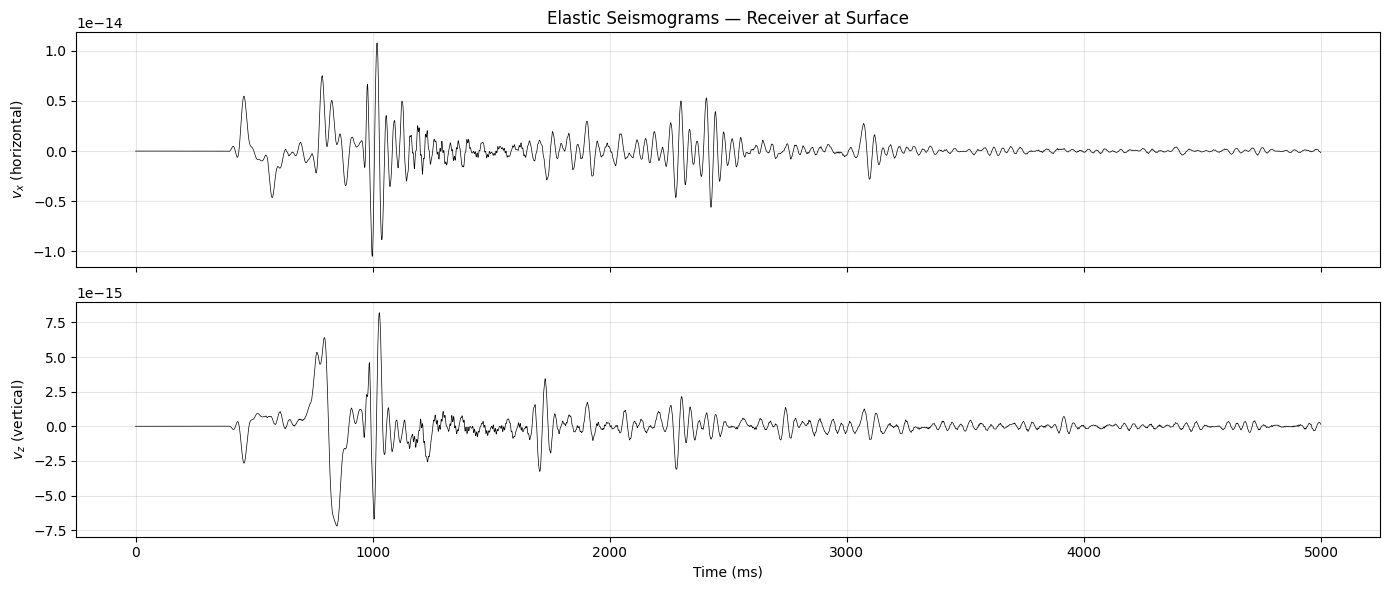

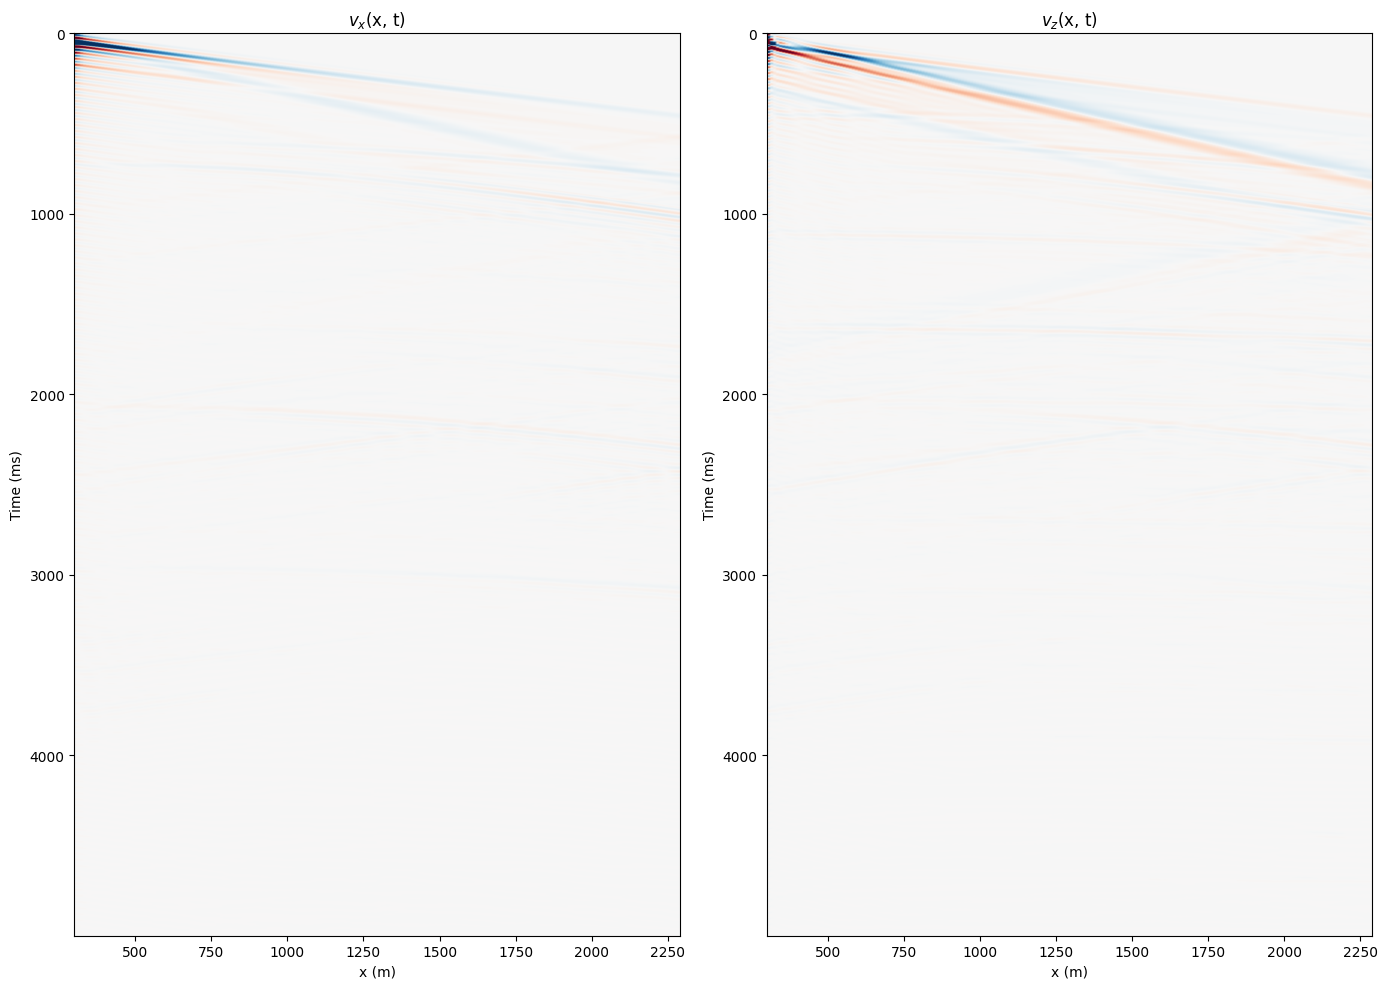

Max vx gather: 8.287323468680295e-13
Max vz gather: 5.274535597388848e-13


In [155]:
# Quick verification plot
t_ms = times * 1e3

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, (key, label) in zip(axes, [('vx', '$v_x$ (horizontal)'),
                                     ('vz', '$v_z$ (vertical)')]):
    ax.plot(t_ms, traces[key], 'k', lw=0.5)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (ms)')
axes[0].set_title('Elastic Seismograms — Receiver at Surface')
plt.tight_layout()
plt.show()

# Check surface gather
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
gather_vx = surface_gather['vx'][n_sponge:nx - n_sponge, :]
gather_vz = surface_gather['vz'][n_sponge:nx - n_sponge, :]
x_phys = np.arange(n_sponge, nx - n_sponge) * dx
extent_xt = [x_phys[0], x_phys[-1], t_ms[-1], t_ms[0]]

for ax, (gather, label) in zip(axes,
        [(gather_vx, '$v_x$(x, t)'), (gather_vz, '$v_z$(x, t)')]):
    vmax = np.abs(gather).max() * 0.1
    if vmax == 0:
        vmax = 1.0
    ax.imshow(gather.T, aspect='auto', extent=extent_xt,
              cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('Time (ms)')
    ax.set_title(label)
plt.tight_layout()
plt.show()

print("Max vx gather:", np.abs(gather_vx).max())
print("Max vz gather:", np.abs(gather_vz).max())